### Calculo de la magntiud asboluta, reducida y observada de asteroides usando sus elementos orbitales y asumiento propiedades fisicas

$$
H(\alpha) = V(r, \Delta, \alpha) - 5 \log(r \Delta)
$$

$$
H(\alpha) = H -2.5\log{[(1-G)\phi_1(\alpha) + G\phi_2(\alpha)]}
$$

$$
V(r, \Delta, \alpha) = H - 2.5\log{[(1-G)\phi_1(\alpha) + G\phi_2(\alpha)]} + 5 \log(r \Delta)
$$

Asumumos G = 0.15, donde

$$
\phi_n(\alpha) = W\phi_{ns} + (1 - W)\phi_{nl}
$$

$$
W = exp(-90.56\tan^2{(\alpha/2)})
$$

Y $\phi_{ns}$, $\phi_{nl}$ siguen las siguientes expresiones 

$$
\phi_{ns} = 1 - \frac{C_n}{0.119 + 1.1341\sin{(\alpha)} - 0.754\sin^2{\alpha}}
$$

$$
\phi_{nl} = exp(-A_n(\tan{(\alpha/2)})^{B_n})
$$

Los parametros $A_n$, $B_n$, $C_n$ poseen los valores:

$$
A_1 = 3.332,  
B_1 = 0.631,
C_1 = 0.986
$$

$$
A_2 = 1.862,  
B_2 = 1.218,
C_2 = 0.238
$$

Usnado la relacion entre el tamaño y la magnitud absoluta, obtenemos la magnitud asumiendo albedo geometrico de p = 0.14
$$
D = 1329.22x10^{-0.2 H} / p^{1/2}
$$

$$
H = -\frac{1}{0.2} \log{\frac{p^{1/2} D}{1329.22}} 
$$

references 
- https://iopscience.iop.org/article/10.1086/341950/pdf
- https://britastro.org/asteroids/dymock4.pdf
- https://www.youtube.com/watch?v=NbwwZOeKiEs&list=PLMPXXm646DvAdGLGxgp4k253qmbRKtlu3&index=9&t=4248s

In [23]:
import numpy as np
import rebound as rb
from Utils import *
import matplotlib.pyplot as plt
%load_ext autoreload 
%autoreload 2

deg = np.pi/180
AU = 149597870 #km
rb.horizons.SSL_CONTEXT = 'unverified'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


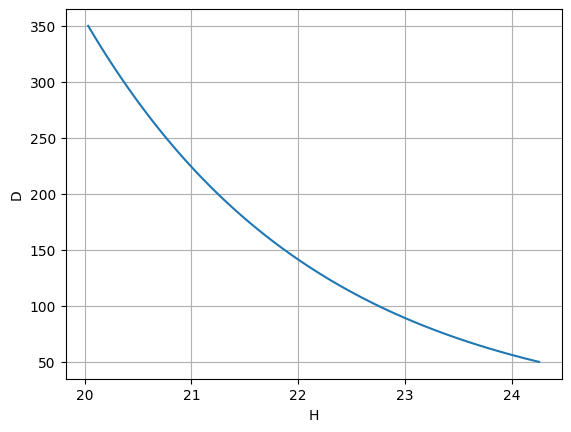

In [24]:
p = 0.14
D = np.linspace(50, 350, 100)
H = H_abs(p, D/1000)

plt.plot(H, D)
plt.xlabel("H")
plt.ylabel("D")
plt.grid()

### TEST USING 433 Eros, 774 Armor, 149 Medusa, 314 Rosalia

| Name        | Type | Date (1997)  | UT   | r*    | g*-r* | Vmea  | Vcat  | ΔV   |
|-------------|------|---------|------|-------|-------|--------|--------|------|
| 433 Eros    | S    | Sep 30  | 1226 | 13.30 | 0.67  | 13.57 | 13.09 | 0.48 |
| 774 Armor   | S    | Sep 28  | 0352 | 12.97 | 0.71  | 13.26 | 12.94 | 0.32 |
| 149 Medusa  | S    | Sep 29  | 0612 | 12.57 | 0.68  | 12.85 | 12.96 | 0.11 |
| 314 Rosalia | C    | Oct 5   | 0315 | 13.95 | 0.46  | 14.13 | 13.81 | 0.32 |


433 Eros

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '433'... 
Found: 433 Eros (A898 PA) 


c:\Users\JuanitaTI\AppData\Local\Programs\Python\Python313\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning:




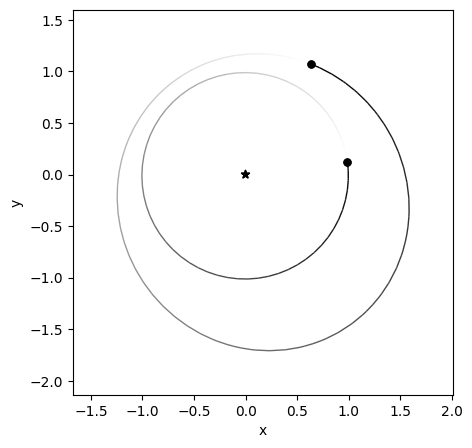

In [25]:
date = '1997-09-30'
diameter = 16.84  #km
p = 0.25

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("433", hash="eros", date=date)

fig = rb.OrbitPlot(sim)

In [26]:
r_eros = np.array(sim.particles['eros'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_eros = r_eros - r_earth

alpha = np.arccos((r_eros @ r_earth_eros) / (mag(r_earth_eros) * mag(r_eros)))

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_eros)
r = mag(r_earth_eros)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)


Absolute Magnitude:  10.99142387866291
Reduced Magnitude:  12.85317536116907
Visual Magnitude:  13.430570343180984


774 Armor

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '774'... 
Found: 774 Armor (A913 YE) 


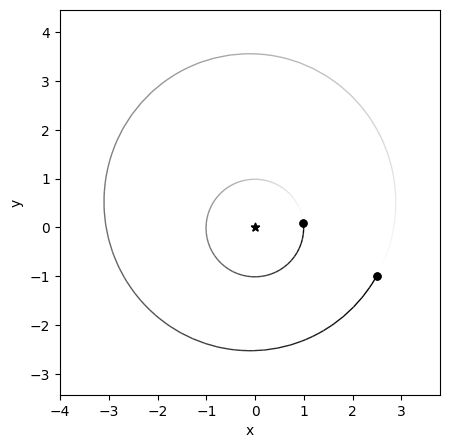

In [27]:
date = '1997-09-28'
diameter = 50.214  #km
p = 0.189

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("774", hash="armor", date=date)

fig = rb.OrbitPlot(sim)

In [28]:
r_armor = np.array(sim.particles['armor'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_armor = r_armor - r_earth

alpha = np.arccos((r_armor @ r_earth_armor) / (mag(r_earth_armor) * mag(r_armor)))

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_armor)
r = mag(r_earth_armor)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

Absolute Magnitude:  8.92270573451706
Reduced Magnitude:  14.81475627802643
Visual Magnitude:  18.332347484952066


149 Medusa

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '149'... 
Found: 149 Medusa (A875 SA) 


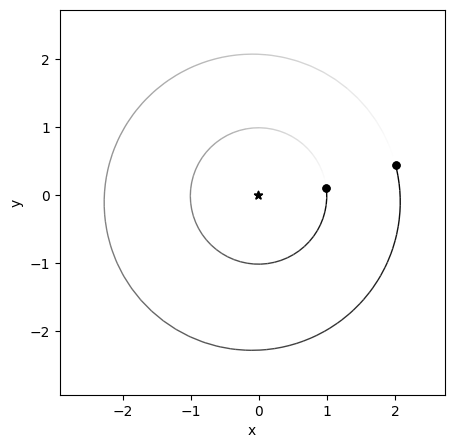

In [29]:
date = '1997-09-29'
diameter = 23.719  #km
p = 0.152

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("149", hash="medusa", date=date)

fig = rb.OrbitPlot(sim)

In [30]:
r_med = np.array(sim.particles['medusa'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_med = r_med - r_earth

alpha = np.arccos((r_med @ r_earth_med) / (mag(r_earth_med) * mag(r_med)))
print('alpha: ', alpha/deg)

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_med)
r = mag(r_earth_med)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

alpha:  5.7153637382521705
Absolute Magnitude:  10.787893490822242
Reduced Magnitude:  nan
Visual Magnitude:  nan


314 Rosalia

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '314'... 
Found: 314 Rosalia (A891 RA) 


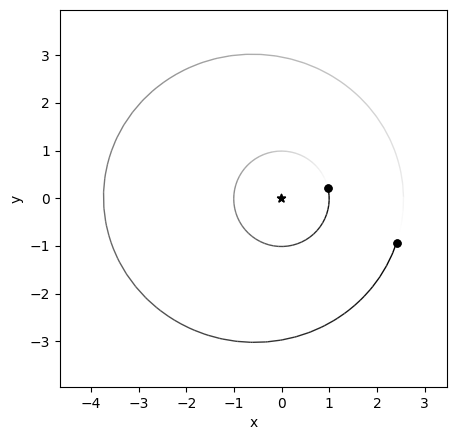

In [31]:
date = '1997-10-05'
diameter = 60.689  #km
p = 0.043

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("314", hash="rosalia", date=date)

fig = rb.OrbitPlot(sim)

In [32]:
r_ros = np.array(sim.particles['rosalia'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_ros = r_ros - r_earth

alpha = np.arccos((r_ros @ r_earth_ros) / (mag(r_earth_ros) * mag(r_ros)))
print('alpha: ', alpha/deg)

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_ros)
r = mag(r_earth_ros)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

alpha:  17.314663557810945
Absolute Magnitude:  10.118763289794453
Reduced Magnitude:  11.729201102504511
Visual Magnitude:  15.117094208063245


## SIMULACION

Asumimos: G = 0.15, p = 0.14, D = 20 km

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


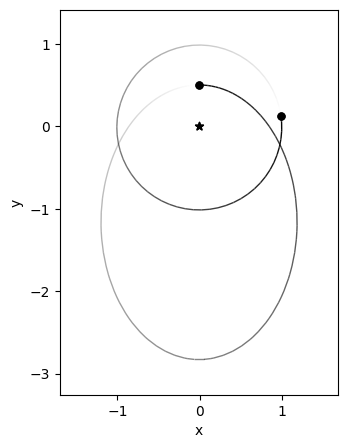

In [59]:
diameter = 20 #km
p = 0.14

q = 0.5
e = 0.7
i = 0
Omega = 0
w = np.pi/2
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=i, Omega=Omega, omega=w, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [60]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*4, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [61]:
state_v

array([[ 2.98618072e-06,  5.00000362e-01,  6.22263086e-12,
        -3.67119883e-07,  5.91731490e-13, -1.78670220e-17],
       [ 4.33757395e-01,  3.85387240e-01,  2.60342197e-11,
        -2.94602239e-07,  1.61436231e-07, -1.28169198e-17],
       [ 7.40213087e-01,  1.38495948e-01,  4.11590271e-11,
        -1.90884058e-07,  2.12268089e-07, -1.30096335e-17],
       [ 9.35069912e-01, -1.35462133e-01,  6.66946689e-11,
        -1.20206668e-07,  2.13721127e-07, -2.99668188e-17],
       [ 1.05717916e+00, -4.00904198e-01,  1.19587431e-10,
        -7.45954608e-08,  2.01921211e-07, -5.14698619e-17],
       [ 1.13138080e+00, -6.48994352e-01,  1.91836244e-10,
        -4.37147961e-08,  1.87321726e-07, -5.97427700e-17],
       [ 1.17231428e+00, -8.78395992e-01,  2.67899062e-10,
        -2.16757336e-08,  1.72821844e-07, -5.86308678e-17],
       [ 1.18899080e+00, -1.08984170e+00,  3.39642695e-10,
        -5.24845365e-09,  1.59195167e-07, -5.35923377e-17],
       [ 1.18727749e+00, -1.28456591e+00,  4.039

In [62]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (mag(r_earth_asteroid) * mag(r_asteroid)))
    print('alpha: ', alpha/deg)

    H_absolute[i] = H_abs(p, diameter)

    H_reducido[i] = H_red(alpha, H)

    Delta = mag(r_asteroid)
    r = mag(r_earth_asteroid)
    mag_visual[i] = V(alpha, r, Delta, H)

alpha:  69.10467188780619
alpha:  95.81685282093535
alpha:  100.32805613346278
alpha:  84.03992365236432
alpha:  63.699280562201686
alpha:  50.99395365645547
alpha:  43.80256986402743
alpha:  39.07981903303423
alpha:  35.35863383160151
alpha:  32.005174466943934
alpha:  28.743827103437564
alpha:  25.45560437116528
alpha:  22.093648519123754
alpha:  18.646337267465682
alpha:  15.12052253726597
alpha:  11.533729084907684
alpha:  7.910528150219981
alpha:  4.2809449704292275
alpha:  0.6799305223481432
alpha:  2.8525089503842906
alpha:  6.270625146508584
alpha:  9.521609600400524
alpha:  12.543432244190402
alpha:  15.261541707761566
alpha:  17.584073145905588
alpha:  19.39526477487742
alpha:  20.54716751276345
alpha:  20.85104547051633
alpha:  20.073495349510484
alpha:  17.950694590324353
alpha:  14.248447123384853
alpha:  8.902900968791602
alpha:  2.2259934232683225
alpha:  4.992784915176459
alpha:  11.719809977001104
alpha:  17.138303913518335
alpha:  20.90636781469415
alpha:  23.07188608

In [63]:
H_reducido

array([12.54457922, 13.54581219, 13.75889501, 13.05956578, 12.37685989,
       12.00642436, 11.80517703, 11.67390617, 11.57029091, 11.47741985,
       11.39158601, 11.32360727, 11.31613543, 11.50960593, 12.80663305,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, 12.66316604, 11.67263938,
       11.43499476, 11.36208871, 11.34916169, 11.38703648, 11.60682518,
       17.76896279,         nan,         nan,         nan,         nan,
       11.77067197, 11.34704214, 11.30710571, 11.30765735, 11.30673161,
       11.31207458, 11.36164593, 11.56634986, 12.47914592,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, 11.31696573, 11.89655636,
       12.17401973, 12.09986888, 11.9141089 , 11.72630508, 11.55975547,
       11.41624787, 11.31697605, 11.36241165, 12.02446107,         nan,
               nan,         nan,         nan,         nan,      

In [64]:
mag_visual

array([11.1746082 , 11.78108698, 11.84713243, 11.32174911, 11.37209458,
       11.93098105, 12.57768789, 13.16868405, 13.67651642, 14.10410929,
       14.46371112, 14.77800277, 15.09836952, 15.57171328, 17.10547354,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, 17.53132624, 16.448615  ,
       16.08918004, 15.8657966 , 15.6758678 , 15.51484663, 15.52289058,
       21.47635318,         nan,         nan,         nan,         nan,
       15.23449442, 14.92164086, 14.99321412, 15.08836309, 15.1544092 ,
       15.19282106, 15.23766286, 15.39697854, 16.22106709,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, 10.67409174, 11.14811857,
       11.81911009, 12.30610956, 12.73874789, 13.16045147, 13.55472831,
       13.90915611, 14.24427819, 14.66487364, 15.64820287,         nan,
               nan,         nan,         nan,         nan,      

In [65]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = "Parameters:\nFrequency = 1 Hz\nAmplitude = 1.0"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


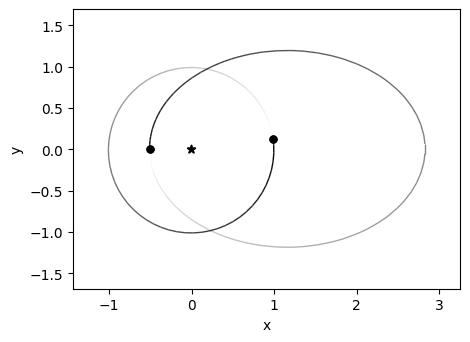

In [66]:
diameter = 20 #km
p = 0.14

q = 0.5
e = 0.7
i = 0
Omega = 0
w = np.pi
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=i, omega=w, Omega=Omega, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [67]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*4, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [68]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (mag(r_earth_asteroid) * mag(r_asteroid)))
    print('alpha: ', alpha/deg)

    H_absolute[i] = H_abs(p, diameter)

    H_reducido[i] = H_red(alpha, H)

    Delta = mag(r_asteroid)
    r = mag(r_earth_asteroid)
    mag_visual[i] = V(alpha, r, Delta, H)

alpha:  4.607676429840684
alpha:  26.128143353446507
alpha:  33.34057834242657
alpha:  32.27865115902259
alpha:  28.473376605809914
alpha:  24.034006740658636
alpha:  19.599128787246624
alpha:  15.319486714465452
alpha:  11.20515528153893
alpha:  7.236142706066577
alpha:  3.395216536645543
alpha:  0.3233594550338497
alpha:  3.9118769151042034
alpha:  7.348544389031229
alpha:  10.59642292438999
alpha:  13.601339219870871
alpha:  16.288469134207908
alpha:  18.55735051086279
alpha:  20.27524597038781
alpha:  21.269480911937116
alpha:  21.321583557622688
alpha:  20.171657432420783
alpha:  17.552738334568616
alpha:  13.28838124702816
alpha:  7.4729377685913585
alpha:  0.6513198718775606
alpha:  6.231916832752942
alpha:  12.21709243983394
alpha:  16.72674961083421
alpha:  19.636494671835433
alpha:  21.101824443928685
alpha:  21.374849082601507
alpha:  20.70299398488963
alpha:  19.293051146680668
alpha:  17.30684062751528
alpha:  14.86785156252489
alpha:  12.06989572081884
alpha:  8.984691449

In [69]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = "Parameters:\nFrequency = 1 Hz\nAmplitude = 1.0"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()

In [70]:
mag_visual

array([        nan, 11.02370663, 11.84964749, 12.48405632, 12.99220411,
       13.45274067, 14.02875748, 15.61990111,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan, 16.48887324, 15.94042371, 15.73178666, 15.5951752 ,
       15.46972658, 15.37279367, 15.51681024,         nan,         nan,
               nan,         nan,         nan, 15.75767694, 15.46131512,
       15.55228251, 15.69356272, 15.84250084, 16.02882177, 16.38455824,
       17.83387752,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan, 15.2094761 ,
       14.47354604, 14.08433023, 13.7371997 , 13.35857991, 12.94356787,
       12.51492811, 12.08187411, 11.5503255 , 10.85292463,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan, 15.90920499,
       15.383748  , 15.25944788, 15.21153047, 15.15918351, 15.07